# Análisis de Distribución y Desviaciones Usando Histogramas y Boxplots

**Preparacion del entorno**
Primero debemos preparar el entorno de trabajo con Pandas

**Cargar los datos**
Una vez seleccionado y descargado el dataset de Kaggle se realiza la carga del archivo csv en un DataFrame de Pandas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/Users/carlis/mi_proyecto/Visualizacion avanzada/2019.csv")

**Exploracion inicial de los datos**
En esta parte comenzamos a revisar y explorar la informacion del DataFrame utilizando las operaciones basicas como Head, Tail, Info, Describe y Types.

Con Head y Tail podemos visualizar las primeras y ultimas filas respectivamente.

Con Info entrega un resumen conciso del DataFrame.

Con Describe "genera estadisticas descriptivas que resumen la tendencia central, dispersion y forma de la distribucion de un conjunto de datos".

In [2]:
print("Primeras filas del DataFrame:")
print(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Estadisticas descriptivas del DataFrame:")
print(df.describe().round(2))

Primeras filas del DataFrame:
   Overall rank Country or region  Score  GDP per capita  Social support  \
0             1           Finland  7.769           1.340           1.587   
1             2           Denmark  7.600           1.383           1.573   
2             3            Norway  7.554           1.488           1.582   
3             4           Iceland  7.494           1.380           1.624   
4             5       Netherlands  7.488           1.396           1.522   
5             6       Switzerland  7.480           1.452           1.526   
6             7            Sweden  7.343           1.387           1.487   
7             8       New Zealand  7.307           1.303           1.557   
8             9            Canada  7.278           1.365           1.505   
9            10           Austria  7.246           1.376           1.475   

   Healthy life expectancy  Freedom to make life choices  Generosity  \
0                    0.986                         0.596     

Con Types nos permite saber los tipos de datos de cada columna.

In [3]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
Overall rank                      int64
Country or region                   str
Score                           float64
GDP per capita                  float64
Social support                  float64
Healthy life expectancy         float64
Freedom to make life choices    float64
Generosity                      float64
Perceptions of corruption       float64
dtype: object


**Limpieza de datos**
En este punto se revisaron los tipos de datos, valores nulos, registros duplicados y posibles inconsistencias dentro del DataFrame.

Primero se verifico la existencia de valores faltantes utilizando funciones como isnull().sum(). Para este dataset no se encontraron datos nulos, por lo que no fue necesario aplicar tecnicas de imputacion o eliminacion de registros.

Posteriormente, se reviso la existencia de rigistros duplicados mediante duplicated().sum(), confirmando que el DataFrame no contenia filas duplicadas.

In [4]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
Overall rank                    0
Country or region               0
Score                           0
GDP per capita                  0
Social support                  0
Healthy life expectancy         0
Freedom to make life choices    0
Generosity                      0
Perceptions of corruption       0
dtype: int64


In [5]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


Tercero, se verifico que la columan Country or region presentara valores unicos y consistentes mediante unique() con el fin de evitar problemas de duplicidad o errores en los nombres de los paises.

Tambien revisaremos si los datos de la columna Score estan dentro de los rangos que corresponden, es decir entre 0 y 10, para este caso podemos verificar que los datos de esta columna estan correctos.

In [6]:
print(df['Country or region'].unique())

<StringArray>
[                 'Finland',                  'Denmark',
                   'Norway',                  'Iceland',
              'Netherlands',              'Switzerland',
                   'Sweden',              'New Zealand',
                   'Canada',                  'Austria',
 ...
                    'Haiti',                 'Botswana',
                    'Syria',                   'Malawi',
                    'Yemen',                   'Rwanda',
                 'Tanzania',              'Afghanistan',
 'Central African Republic',              'South Sudan']
Length: 156, dtype: str


In [7]:
df['Country or region'] = df['Country or region'].str.strip()

In [8]:
df[df['Score'] < 0]

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


In [9]:
df[df['Score'] > 10]

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption


Finalmente, se realizo una revision de los datos atipicos (outliers) utilizando graficos tipo boxplot para identificar valores extremadamente altos o bajo dentro de la variables analizadas.

Comence a revisar la informacion completa para luego centrarme en las columnas Score, GDP per capita, Healthy life expectancy y Freedom to make life choices, estos boxplots nos permiten identificar paises cuyos indicares se alejan considerablemente del comportamiento general del conjunto de datos.

En la variable Score se puede observar algunos valores extremos superiores e inferiores, lo que representa paises con niveles de felicidad excepcionalmente altos o bajos.

En GDP per capita se identifican outliers superiores asociados a paises con economias mas desarrolladas y con mayores ingresos por habitante.

Para Healthy life expectancy, los valores atipicos inferiores corresponden a paises con menores condiciones de salud y esperanza de vida.

En Freedom to make life choices se detectan diferencias importantes entre paises, reflejando distintas percepciones de libertad personal y calidad de vida.

A pesar de la presencia de algunos outliers no fueron eliminados debido a que representan comportamientos reales e importantes dentro del analisis global de felicidad.

In [10]:
print("Estadisticas descriptivas del DataFrame:")
display(df.describe().round(2))

Estadisticas descriptivas del DataFrame:


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.00,156.00,156.00,156.00,156.00,156.00,156.00,156.00
mean,78.50,5.41,0.91,1.21,0.73,0.39,0.18,0.11
std,45.18,1.11,0.40,0.30,0.24,0.14,0.10,0.09
min,1.00,2.85,0.00,0.00,0.00,0.00,0.00,0.00
25%,39.75,4.54,0.60,1.06,0.55,0.31,0.11,0.05
50%,78.50,5.38,0.96,1.27,0.79,0.42,0.18,0.09
75%,117.25,6.18,1.23,1.45,0.88,0.51,0.25,0.14
max,156.00,7.77,1.68,1.62,1.14,0.63,0.57,0.45


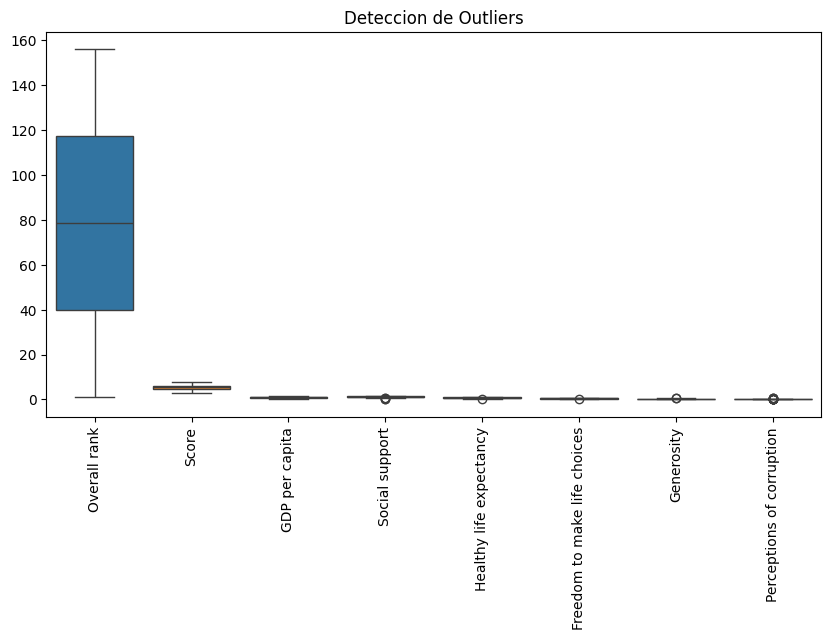

In [11]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df.select_dtypes(include=np.number))
plt.xticks(rotation=90)
plt.title('Deteccion de Outliers')
plt.show()

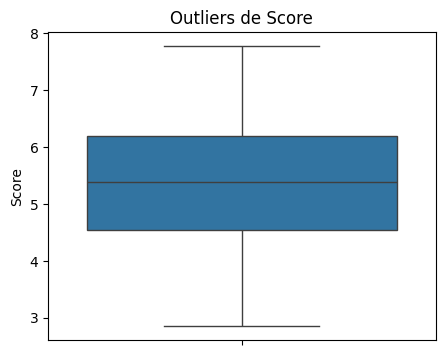

In [12]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Score'])
plt.title('Outliers de Score')
plt.show()

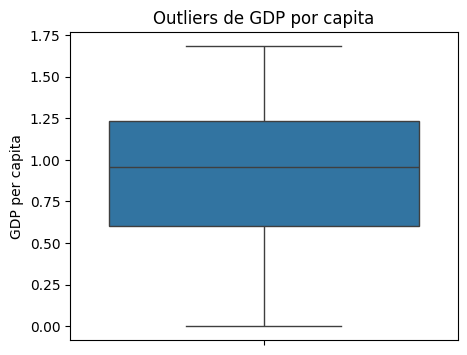

In [13]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['GDP per capita'])
plt.title('Outliers de GDP por capita')
plt.show()

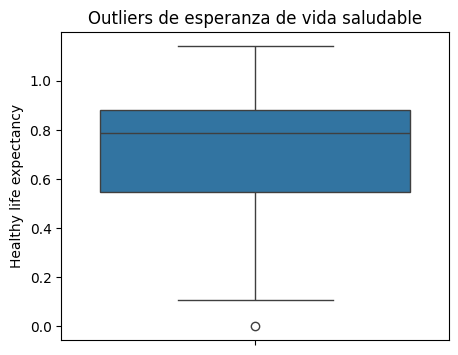

In [14]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Healthy life expectancy'])
plt.title('Outliers de esperanza de vida saludable')
plt.show()

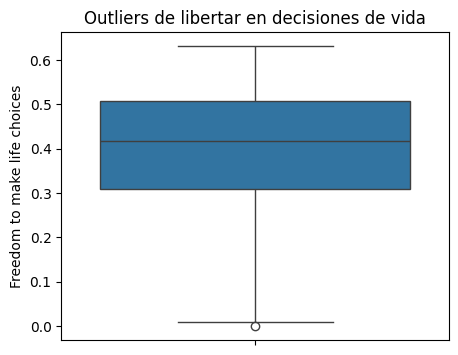

In [15]:
plt.figure(figsize=(5,4))
sns.boxplot(y=df['Freedom to make life choices'])
plt.title('Outliers de libertar en decisiones de vida')
plt.show()

In [16]:
Q1 = df['Score'].quantile(0.25)
Q3 = df['Score'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[(df['Score'] < limite_inferior) | (df['Score'] > limite_superior)]
print("Cantidad de outliers:", len(outliers))


Cantidad de outliers: 0


Para cerrar la limpieza de datos verifico la existencia de valores faltantes mediante isnull().sum().sum(), obteniendo como resultado 0, lo que confirma que el dataset no presenta datos nulos y por lo tanto no es necesario aplicar tecnicas de imputacion.

In [18]:
df.isnull().sum().sum()

np.int64(0)

# Graficos

De acuerdo con lo solicitado en las instrucciones se realizan Histogramas y boxplot con las variables Score, GDP per capita, Healthy life expectancy y Freedom to make life choices.

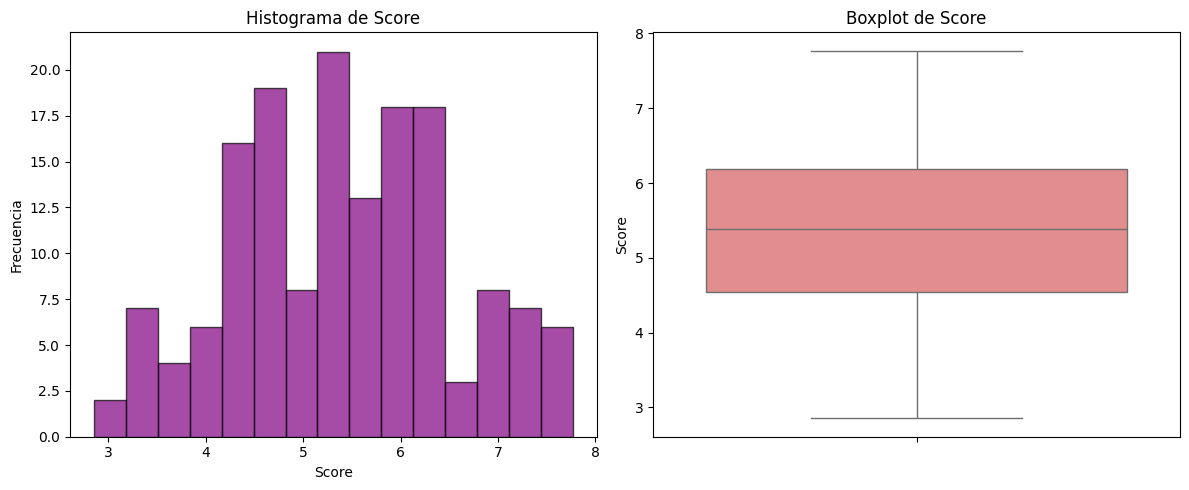

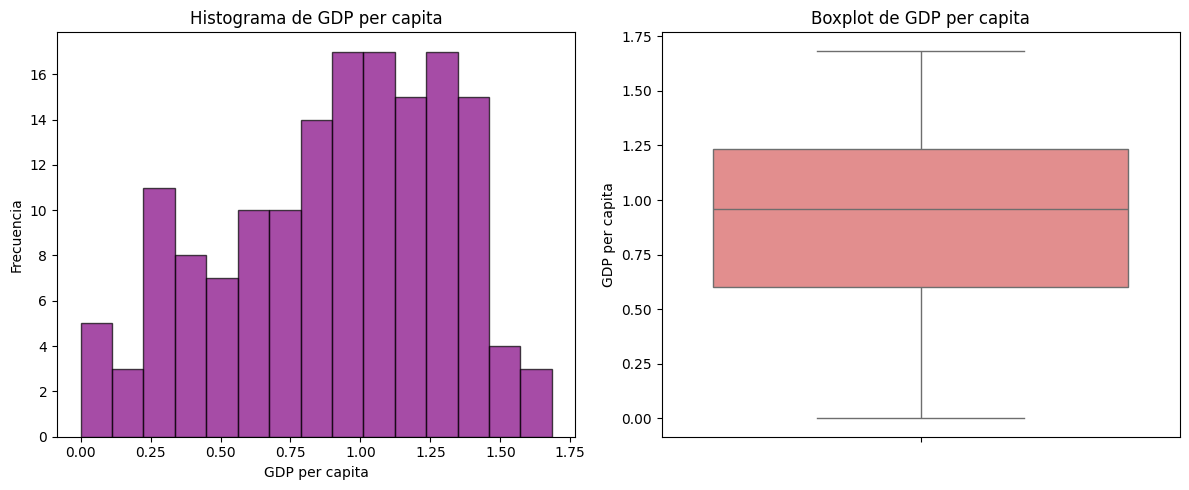

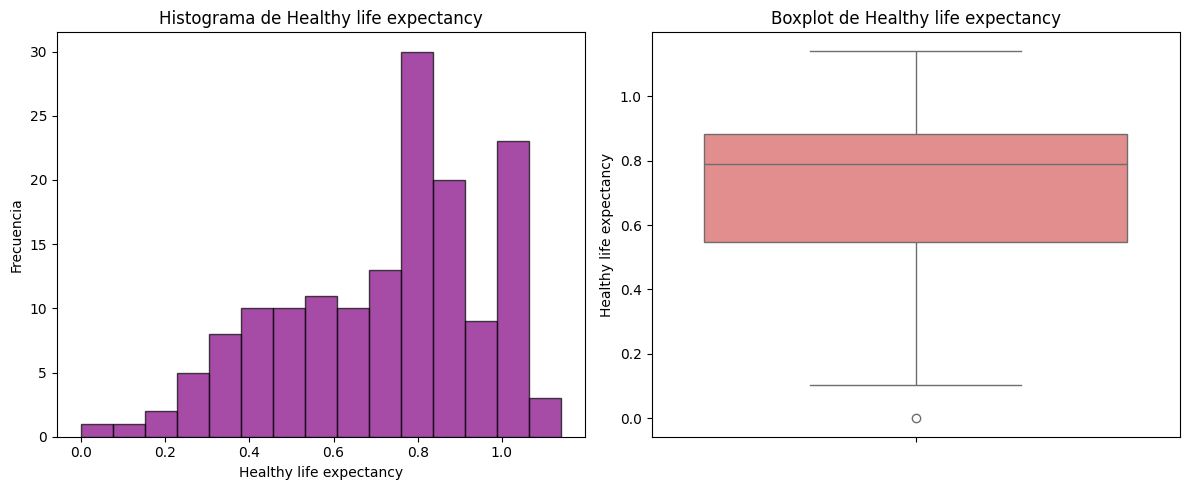

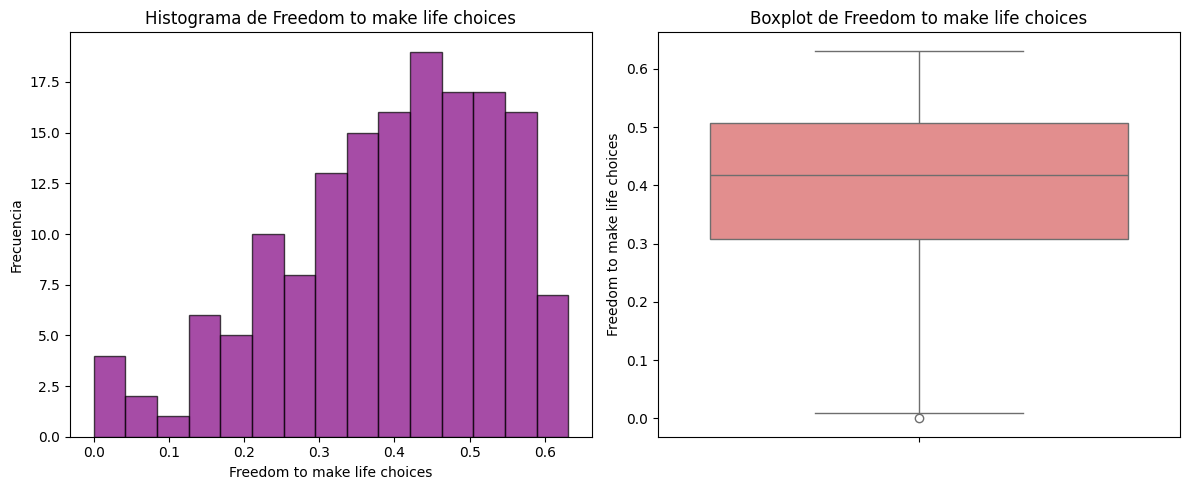

In [17]:
variables = ['Score', 'GDP per capita', 'Healthy life expectancy', 'Freedom to make life choices']

for variable in variables:
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.hist(df[variable], bins=15, color='purple', edgecolor='black', alpha=0.7)
    plt.title(f'Histograma de {variable}')
    plt.xlabel(variable)
    plt.ylabel('Frecuencia')

    plt.subplot(1,2,2)
    sns.boxplot(y=df[variable], color='lightcoral')
    plt.title(f'Boxplot de {variable}')
    plt.tight_layout()
    plt.show()
    

**Analisis Graficos**

1.Score

Histograma: en este grafico se muestra una concentracion moderada de valores medios, es decir la mayoria de los paises presentan un puntaje de felicidad entre 4 y 7.

Boxplot: en este grafico podemos observar que existen algunos valores atipicos superiores e inferiores, lo que representa paises con niveles de felicidad extramadamente altos o bajos.

2.GDP per capita

Histograma: en este grafico observamos un sesgo hacia la derecha lo que indica que la mayoria de los paises tiene un PIB per capita moderado o bajo, mientras pocos paises poseen valores muy altos.

Boxplot: este grafico confirma la existencia de outliers superiores que corresponde a paises con economias significativamente mas desarrolladas.

3.Healthy life expectancy

Histograma: en este caso la distribucion es relativamente simetrica, aunque existe una ligera concentracion en valores altos de expectativa de vida saludable.

Boxplot: para este caso se observan algunos valores atipicos inferiores, lo que indica paises con expectativas de visa considerablemente menores.

4.Freedom to make life choices

Histograma: en este grafico observamos que la mayoria de los paises presentan niveles medios-altos de libera para tomar decisiones de visa, con una distribucion levemente sesgada.

Boxplot: este grafico evidencia algunos valores atipicos, reflejando diferencias importantes entre paises respecto a la percepcion de libertad personal.
